In [ ]:
import os
from glob import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention 
from tensorflow.keras import regularizers 
from tensorflow.keras import Model 

2025-06-17 02:28:49.807621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750127329.983315      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750127330.031674      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
class SqueezeLayer(tf.keras.layers.Layer):
    def __init__(self, axis=None, **kwargs):
        super(SqueezeLayer, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.squeeze(inputs, axis=self.axis)

    def get_config(self):
        config = super(SqueezeLayer, self).get_config()
        config.update({'axis': self.axis})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [3]:
# Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.2, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
            Dense(d_model, kernel_regularizer=regularizers.l2(0.005))
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.rate = rate

    def call(self, x, training=False):
        attn_output = self.mha(x, x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

    def get_config(self):
        config = super(TransformerBlock, self).get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'dff': self.dff,
            'rate': self.rate
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = {k: v for k, v in config.items() if k in ['d_model', 'num_heads', 'dff', 'rate']}
        return cls(**config)

# Temporal Attention Layer
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.query = Dense(input_shape[-1], use_bias=False)
        self.key = Dense(input_shape[-1], use_bias=False)
        self.value = Dense(input_shape[-1], use_bias=False)

    def call(self, x):
        q = self.query(x)  # (batch_size, n_frames, d_model)
        k = self.key(x)
        v = self.value(x)
        attention_scores = tf.matmul(q, k, transpose_b=True)  # (batch_size, n_frames, n_frames)
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)
        attended_output = tf.matmul(attention_weights, v)  # (batch_size, n_frames, d_model)
        return tf.reduce_sum(attended_output, axis=1)  # (batch_size, d_model)

    def get_config(self):
        config = super(TemporalAttention, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [ ]:

# List of emotions from VESC
EMOTIONS = ['angry', 'happiness', 'anxiety', 'neutral', 'sadness']
NUM_CLASSES = len(EMOTIONS)

# Actual calculation needed from the data
GLOBAL_MEAN_PITCH = 0.0
GLOBAL_JITTER = 0.0
GLOBAL_PITCH_SLOPE = 0.0

# Function to add noise
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

# Function to change pitch
def pitch_shift(audio, sr, n_steps=2): # Random n_steps
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

# Function to apply time stretching
def time_stretch(audio, rate=0.95): # Random rate
    return librosa.effects.time_stretch(audio, rate=rate)

# Function to apply time shifting
def time_shift(audio, shift_max=0.2, sr=24200):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# Function to normalize pitch
def normalize_pitch(pitches):
    pitches = pitches[pitches > 0]
    if len(pitches) == 0:
        return GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE

    mean_pitch = np.mean(pitches)
    normalized_pitches = pitches - mean_pitch
    jitter = np.std(normalized_pitches) if len(normalized_pitches) > 0 else 0

    # Check if there are enough points for polyfit
    if len(pitches) > 1:
        slope = np.polyfit(np.arange(len(pitches)), pitches, 1)[0]
    else:
        slope = 0 # Fallback for single point

    # Handle NaN values that might arise from edge cases
    if np.isnan(mean_pitch): mean_pitch = GLOBAL_MEAN_PITCH
    if np.isnan(jitter): jitter = GLOBAL_JITTER
    if np.isnan(slope): slope = GLOBAL_PITCH_SLOPE

    return mean_pitch, jitter, slope

# Feature extraction
def extract_features(audio_path, sample_rate=24200, duration=10, n_mfcc=26, n_frames=157, augment_type='normal', global_pitch_params=None):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        if augment_type == 'noise':
            audio = add_noise(audio)
        elif augment_type == 'pitch':
            audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch':
            audio = time_stretch(audio)
        elif augment_type == 'shift':
            audio = time_shift(audio)

        hop_length = target_length // (n_frames - 1)

        # MFCCs + Delta + Delta-Delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=2048)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_features = np.concatenate((mfcc, mfcc_delta, mfcc_delta2), axis=0)

        # Pad or truncate MFCCs
        if mfcc_features.shape[1] > n_frames:
            mfcc_features = mfcc_features[:, :n_frames]
        elif mfcc_features.shape[1] < n_frames:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, n_frames - mfcc_features.shape[1])), mode='constant')

        # Pitch features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, hop_length=hop_length)
        if global_pitch_params:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches)
            # If normalize_pitch returns fallback values (0,0,0), use global defaults
            if mean_pitch == 0 and jitter == 0 and pitch_slope == 0:
                mean_pitch, jitter, pitch_slope = global_pitch_params
        else:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches) # Will use current GLOBAL_*

        pitch_features_single = np.array([mean_pitch, jitter, pitch_slope])
        pitch_features = np.tile(pitch_features_single, (n_frames, 1)).T # Tile to match n_frames

        # Energy features (RMS + mean and std)
        energy = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
        if len(energy) > n_frames:
            energy = energy[:n_frames]
        elif len(energy) < n_frames:
            energy = np.pad(energy, (0, n_frames - len(energy)), mode='constant')

        mean_energy = np.mean(energy)
        shimmer = np.std(energy) if len(energy) > 0 else 0
        energy_features = np.array([energy, np.full(n_frames, mean_energy), np.full(n_frames, shimmer)])

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=hop_length)[0]
        if len(zcr) > n_frames:
            zcr = zcr[:n_frames]
        elif len(zcr) < n_frames:
            zcr = np.pad(zcr, (0, n_frames - len(zcr)), mode='constant')
        zcr_features = zcr[np.newaxis, :]

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length, n_chroma=12)
        if chroma.shape[1] > n_frames:
            chroma = chroma[:, :n_frames]
        elif chroma.shape[1] < n_frames:
            chroma = np.pad(chroma, ((0, 0), (0, n_frames - chroma.shape[1])), mode='constant')

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length, n_bands=5)

        # Pad or truncate spectral features
        # Assuming all spectral features have the same number of frames
        if spectral_centroid.shape[0] > n_frames:
            spectral_centroid = spectral_centroid[:n_frames]
            spectral_rolloff = spectral_rolloff[:n_frames]
            spectral_contrast = spectral_contrast[:, :n_frames]
        elif spectral_centroid.shape[0] < n_frames:
            spectral_centroid = np.pad(spectral_centroid, (0, n_frames - spectral_centroid.shape[0]), mode='constant')
            spectral_rolloff = np.pad(spectral_rolloff, (0, n_frames - spectral_rolloff.shape[0]), mode='constant')
            spectral_contrast = np.pad(spectral_contrast, ((0, 0), (0, n_frames - spectral_contrast.shape[1])), mode='constant')
        spectral_features = np.vstack([spectral_centroid, spectral_rolloff, spectral_contrast])

        # Temporal features
        voiced_frames = librosa.effects.split(audio, top_db=20)
        speech_rate = len(voiced_frames) / (duration if duration > 0 else 1)
        pauses = len(voiced_frames) - 1 if len(voiced_frames) > 1 else 0
        temporal_features_single = np.array([speech_rate, pauses])
        temporal_features = np.tile(temporal_features_single, (n_frames, 1)).T

        features = np.concatenate([
            mfcc_features, # Now includes delta and delta-delta
            pitch_features,
            energy_features,
            zcr_features,
            chroma,
            spectral_features,
            temporal_features
        ], axis=0)

        return np.expand_dims(features, axis=-1)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Build Transformer model
def build_transformer_model(input_shape, num_classes=NUM_CLASSES):
    # input_shape here is (num_features, n_frames, 1)
    inputs = layers.Input(shape=input_shape)

    # Use the custom SqueezeLayer instead of direct tf.squeeze
    x = SqueezeLayer(axis=-1)(inputs) # Shape becomes (batch_size, num_features, n_frames)

    # Transpose to (batch_size, n_frames, num_features) to align with transformer expectation (sequence_length, feature_dimension)
    x = layers.Permute((2, 1))(x)

    # Apply a Dense layer to project to d_model (128)
    # The input to the Transformer Block should be (batch_size, sequence_length, d_model)
    # Here, sequence_length is n_frames and d_model is the output of this Dense layer
    d_model = 128
    x = layers.Dense(d_model, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x)

    # Add positional encoding
    pos_encoding = positional_encoding(input_shape[1], d_model) # input_shape[1] is n_frames
    x = x + pos_encoding

    # Stack 3 Transformer blocks
    for _ in range(3):
        x = TransformerBlock(d_model=d_model, num_heads=8, dff=256, rate=0.2)(x, training=True)

    # Add Temporal Attention
    x = TemporalAttention()(x)

    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.summary()
    return model

# Positional Encoding
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rads = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

# Train and evaluate
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=32, checkpoint_path='best_transformer_vnemos.h5'):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

    class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=np.argmax(y, axis=1))
    class_weight_dict = dict(enumerate(class_weights))

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr, checkpoint],
                        class_weight=class_weight_dict,
                        verbose=1)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nĐánh giá trên tập kiểm tra: Loss={val_loss:.4f}, Accuracy={val_accuracy:.4f}")
    return model, history

# Add a function to calculate GLOBAL_PITCH_PARAMS
def calculate_global_pitch_params(audio_files, sample_rate=24200):
    all_pitches = []
    for audio_path in audio_files:
        try:
            audio, sr = librosa.load(audio_path, sr=sample_rate)
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
            pitches = pitches[pitches > 0]
            if len(pitches) > 0:
                all_pitches.extend(pitches)
        except Exception as e:
            print(f"Error calculating global pitch for {audio_path}: {e}")
            continue

    if len(all_pitches) == 0:
        print("Warning: No valid pitches found to calculate global parameters. Using default zeros.")
        return 0.0, 0.0, 0.0

    all_pitches = np.array(all_pitches)
    global_mean_pitch = np.mean(all_pitches)

    normalized_all_pitches = all_pitches - global_mean_pitch
    global_jitter = np.std(normalized_all_pitches) if len(normalized_all_pitches) > 0 else 0

    # Calculate global pitch slope (simple average of local slopes, or fit a line to all pitches)
    # For simplicity, let's use the average of slopes calculated over reasonable segments
    # A more robust approach might involve fitting a trend line to all valid pitch values,
    # but that's computationally intensive. For global, a simple average might suffice or set to 0.
    global_pitch_slope = 0.0 # Often jitter is more informative than overall slope for global

    # Consider replacing NaN/inf with 0 in case of edge issues
    global_mean_pitch = 0.0 if np.isnan(global_mean_pitch) or np.isinf(global_mean_pitch) else global_mean_pitch
    global_jitter = 0.0 if np.isnan(global_jitter) or np.isinf(global_jitter) else global_jitter
    global_pitch_slope = 0.0 if np.isnan(global_pitch_slope) or np.isinf(global_pitch_slope) else global_pitch_slope

    return global_mean_pitch, global_jitter, global_pitch_slope


# Function to prepare data with label mapping from directory
def prepare_training_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    skipped_files = 0
    processed_files = 0

    print(f"Total number of audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]

        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type, global_pitch_params=global_pitch_params)
            if features is None or np.all(features == 0):
                continue
            X.append(features)
            y.append(emotion_idx)
            processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No audio files were successfully processed. Please check the data path or emotion_map.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Function to prepare test data
def prepare_test_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    skipped_files = 0
    processed_files = 0

    print(f"Total number of test audio files: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal', global_pitch_params=global_pitch_params)
        if features is None or np.all(features == 0):
            continue
        X.append(features)
        y.append(emotion_idx)
        processed_files += 1

    print(f"Processed: {processed_files} samples, skipped: {skipped_files} files.")
    if not X or not y:
        raise ValueError("No test audio files were successfully processed.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Test dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# Evaluate the model using confusion matrix and F1 Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # Print sample probabilities for debugging
    print("\nSample prediction probabilities:")
    for i in range(min(5, len(X_test))):
        print(f"Sample {i+1}: True={EMOTIONS[y_true_classes[i]]}, Pred={EMOTIONS[y_pred_classes[i]]}, Prob={y_pred[i]}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns_heatmap  = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=EMOTIONS))

    print("\nEvaluation metric formulas:")
    print("1. Precision = TP / (TP + FP)")
    print("   - TP (True Positives): Number of samples correctly predicted for a class.")
    print("   - FP (False Positives): Number of samples incorrectly predicted as that class.")
    print("2. Recall = TP / (TP + FN)")
    print("   - FN (False Negatives): Number of samples that belong to the class but were incorrectly predicted.")
    print("3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")


# Train and evaluate
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=16, checkpoint_path='best_model.h5', class_weight=None):
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Training dataset is empty. Please check the input data.")

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr, checkpoint],
                        class_weight=class_weight,
                        verbose=1)

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nEvaluation on the test set:")
    print(f" - Loss: {val_loss:.4f}")
    print(f" - Accuracy: {val_accuracy:.4f}")
    return model, history, X_val, y_val

# Direct prediction using CNN
def predict_emotion(audio_path, model, scaler, global_pitch_params):
    features = extract_features(audio_path, augment_type='normal', global_pitch_params=global_pitch_params)
    if features is None or np.all(features == 0):
        return "Prediction failed: Feature extraction error."

    # Reshape features for scaling
    original_shape = features.shape
    features_2d = features.reshape(1, -1)
    features_2d = scaler.transform(features_2d)  # Apply scaler
    features = features_2d.reshape(original_shape) # Reshape back

    features = np.expand_dims(features, axis=0) # Add batch dimension
    prediction = model.predict(features, verbose=0)
    predicted_emotion_idx = np.argmax(prediction, axis=1)[0]

    # Print probabilities for debugging
    print(f"Prediction probabilities for {audio_path}: {prediction[0]}")
    return EMOTIONS[predicted_emotion_idx]

# Plot Loss Chart
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()



Found 144 files in folder: angry
Found 164 files in folder: neutral
Found 109 files in folder: anxiety
Found 140 files in folder: sadness
Found 115 files in folder: happiness
Calculating GLOBAL_PITCH_PARAMS from training data...
GLOBAL_MEAN_PITCH: 1316.5161, GLOBAL_JITTER: 1039.6665, GLOBAL_PITCH_SLOPE: 0.0000
Phân bố nhãn gốc: Counter({'neutral': 164, 'angry': 144, 'sadness': 140, 'happiness': 115, 'anxiety': 109})
Class weights: {0: 0.9333333333333333, 1: 1.1686956521739131, 2: 1.2330275229357799, 3: 0.8195121951219512, 4: 0.96}
Tổng số file âm thanh: 672
Đã xử lý: 3360 mẫu, bỏ qua: 0 file.
Dataset shape: X=(3360, 107, 157, 1), y=(3360, 5)
X shape: (3360, 107, 157, 1)
Calculated Transformer Input Shape: (107, 157, 1)


I0000 00:00:1750127747.823858      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 107, 157, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ squeeze_layer (SqueezeLayer)         │ (None, 107, 157)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 157, 107)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 157, 128)            │          13,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 157, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ (None, 157, 128)            │         132,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_1                  │ (None, 157, 128)            │         132,480 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_2                  │ (None, 157, 128)            │         132,480 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ temporal_attention                   │ (None, 128)                 │          49,152 │
│ (TemporalAttention)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 529,029 (2.02 MB)

...

Train shape: (2688, 107, 157, 1), Val shape: (672, 107, 157, 1)
Epoch 1/100


I0000 00:00:1750127764.541036      90 service.cc:148] XLA service 0x7923d0003790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750127764.541686      90 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1750127765.785031      90 cuda_dnn.cc:529] Loaded cuDNN version 90300


 10/168 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1708 - loss: 70.1302

I0000 00:00:1750127772.955609      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


164/168 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2769 - loss: 47.8928
Epoch 1: val_loss improved from inf to 18.51664, saving model to best_transformer_vesc.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.2786 - loss: 47.5522 - val_accuracy: 0.4479 - val_loss: 18.5166 - learning_rate: 1.0000e-04
Epoch 2/100
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3989 - loss: 22.3636
Epoch 2: val_loss improved from 18.51664 to 15.49801, saving model to best_transformer_vesc.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3992 - loss: 22.3408 - val_accuracy: 0.5536 - val_loss: 15.4980 - learning_rate: 1.0000e-04
Epoch 3/100
166/168 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4443 - loss: 18.4081
Epoch 3: val_loss improved from 15.49801 to 12.73563, saving model to best_transformer_vesc.keras
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4444 - loss: 18.3902 - val_accuracy: 0.5521 - val_loss: 12.7356 - learning_rate: 1.0000e-04
Epoch 4/100

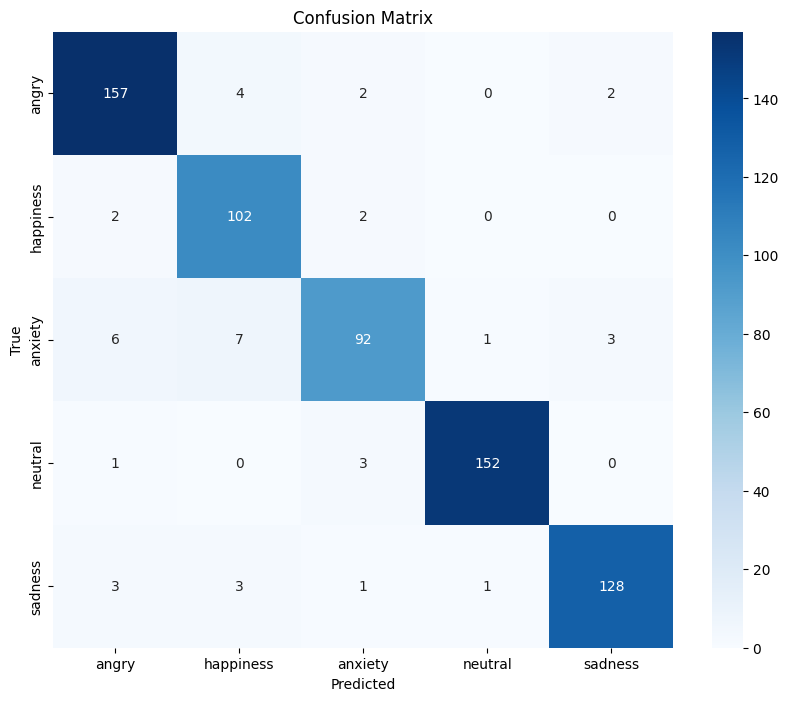


Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.95      0.94       165
   happiness       0.88      0.96      0.92       106
     anxiety       0.92      0.84      0.88       109
     neutral       0.99      0.97      0.98       156
     sadness       0.96      0.94      0.95       136

    accuracy                           0.94       672
   macro avg       0.94      0.93      0.93       672
weighted avg       0.94      0.94      0.94       672


Công thức các số liệu đánh giá:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Số mẫu dự đoán đúng cho một lớp.
   - FP (False Positives): Số mẫu dự đoán sai là lớp đó.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Số mẫu thuộc lớp đó nhưng dự đoán sai.
3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)


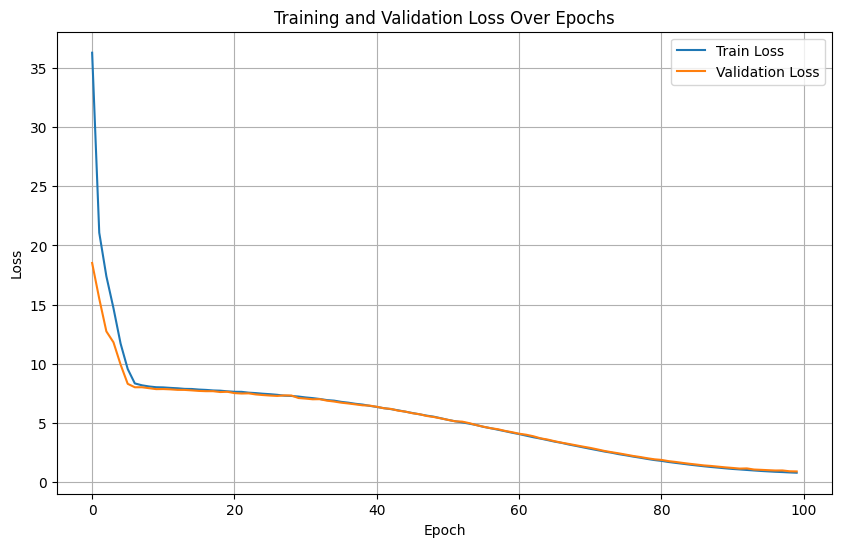

In [ ]:
if __name__ == "__main__":
    # Path to the data
    root_folder = '/kaggle/input/speech-emotion-10/emotion_vi_train/emotion_vi_train'
    folders = [f for f in glob(os.path.join(root_folder, "*")) if os.path.isdir(f)]
    all_files = []
    for folder in folders:
        files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
        all_files.extend(files)
        print(f"Found {len(files)} files in folder: {os.path.basename(folder)}")

    if not all_files:
        raise ValueError("No audio files found in the training directory.")

    # Calculate GLOBAL_PITCH_PARAMS first
    print("Calculating GLOBAL_PITCH_PARAMS from training data...")
    GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE = calculate_global_pitch_params(all_files)
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")

    # Check label distribution
    emotion_map = {
        'angry': 0,
        'happiness': 1,
        'anxiety': 2,
        'neutral': 3,
        'sadness': 4
    }
    y_raw = [emotion_map.get(os.path.basename(os.path.dirname(f)), -1) for f in all_files]
    print("Original label distribution:", Counter([EMOTIONS[i] for i in y_raw if i != -1]))

    # Calculate class weights
    y_raw_train = [y for y in y_raw if y != -1]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_raw_train), y=y_raw_train)
    class_weight_dict = dict(enumerate(class_weights))
    print("Class weights:", class_weight_dict)

    # Prepare data
    X, y = prepare_training_data(all_files, emotion_map,(GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
    print(f"X shape: {X.shape}")

    # Normalize features
    scaler = StandardScaler()
    # Reshape cho scaler (2D)
    original_shape = X.shape
    X_2d = X.reshape(original_shape[0], -1)
    X_2d = scaler.fit_transform(X_2d)
    X = X_2d.reshape(original_shape) 

    calculated_input_dim0 = X.shape[1] # num_features
    calculated_input_dim1 = X.shape[2] # n_frames
    transformer_input_shape = (calculated_input_dim0, calculated_input_dim1, 1) # (num_features, n_frames, 1)

    print(f"Calculated Transformer Input Shape: {transformer_input_shape}")

    # Build and train the model
    model = build_transformer_model(input_shape = transformer_input_shape) # Renamed cnn_model to model
    model, history, X_val_eval, y_val_eval = train_and_evaluate_model( # Renamed X_test, y_test to X_val_eval, y_val_eval
        model, X, y,
        epochs=100,
        batch_size=16,
        checkpoint_path='best_transformer_vesc.keras',
        class_weight=class_weight_dict
    )

    # Save the final model
    model.save('final_transformer_vesc.keras')
    evaluate_model(model, X_val_eval, y_val_eval) # Use X_val_eval, y_val_eval for evaluation
    plot_loss_history(history)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_block_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_block_5', how

Found 37 files in folder: angry
Found 33 files in folder: neutral
Found 20 files in folder: anxiety
Found 101 files in folder: sadness
Found 44 files in folder: happiness
Total test files: 235
Phân bố nhãn gốc (test): Counter({'sadness': 101, 'happiness': 44, 'angry': 37, 'neutral': 33, 'anxiety': 20})
GLOBAL_MEAN_PITCH: 1316.5161, GLOBAL_JITTER: 1039.6665, GLOBAL_PITCH_SLOPE: 0.0000
Tổng số file âm thanh kiểm tra: 235
Đã xử lý: 235 mẫu, bỏ qua: 0 file.
Test dataset shape: X=(235, 107, 157, 1), y=(235, 5)

Sample prediction probabilities:
Sample 1: True=angry, Pred=angry, Prob=[0.7012272  0.0683168  0.07103999 0.07874509 0.080671  ]
Sample 2: True=angry, Pred=angry, Prob=[0.90060616 0.02498261 0.01345077 0.0433051  0.01765538]
Sample 3: True=angry, Pred=angry, Prob=[0.91745436 0.03294174 0.01072169 0.01962001 0.01926223]
Sample 4: True=angry, Pred=angry, Prob=[0.9835312  0.00259484 0.00417094 0.00487517 0.0048279 ]
Sample 5: True=angry, Pred=angry, Prob=[0.9199866  0.02180346 0.0163590

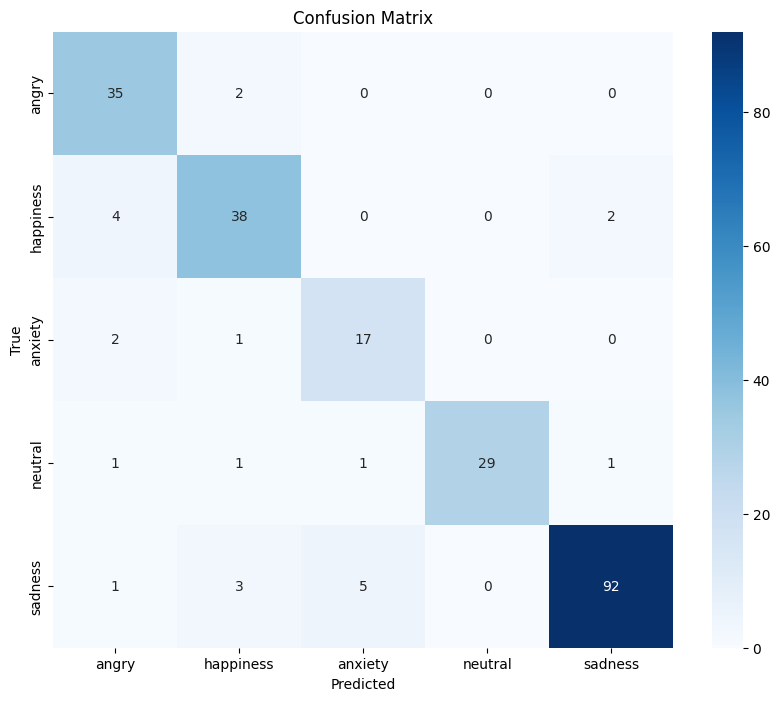


Classification Report:
              precision    recall  f1-score   support

       angry       0.81      0.95      0.88        37
   happiness       0.84      0.86      0.85        44
     anxiety       0.74      0.85      0.79        20
     neutral       1.00      0.88      0.94        33
     sadness       0.97      0.91      0.94       101

    accuracy                           0.90       235
   macro avg       0.87      0.89      0.88       235
weighted avg       0.91      0.90      0.90       235


Công thức các số liệu đánh giá:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Số mẫu dự đoán đúng cho một lớp.
   - FP (False Positives): Số mẫu dự đoán sai là lớp đó.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Số mẫu thuộc lớp đó nhưng dự đoán sai.
3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

Dự đoán trên các file kiểm tra:
Prediction probabilities for /kaggle/input/speech-emotion-10/emotion_vi_test_n_o/emotion_vi_test/angry/angry_caytaonohoa

In [ ]:

    best_model = tf.keras.models.load_model('best_transformer_vesc.keras',
                                            custom_objects={'TransformerBlock': TransformerBlock,
                                                            'TemporalAttention': TemporalAttention,
                                                            'SqueezeLayer': SqueezeLayer}) # Added SqueezeLayer
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                        metrics=['accuracy'])

    # Prepare test data
    root_folder_test = "/kaggle/input/speech-emotion-10/emotion_vi_test_n_o/emotion_vi_test"
    folders_test = [f for f in glob(os.path.join(root_folder_test, "*")) if os.path.isdir(f)]
    all_files_test = []
    for folder in folders_test:
        files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
        all_files_test.extend(files)
        print(f"Found {len(files)} files in folder: {os.path.basename(folder)}")

    if not all_files_test:
        raise ValueError("No audio files found in the test directory.")

    print(f"Total test files: {len(all_files_test)}")

    y_raw_test = [emotion_map.get(os.path.basename(os.path.dirname(f)), -1) for f in all_files_test]
    print("Original label distribution (test):", Counter([EMOTIONS[i] for i in y_raw_test if i != -1]))
    print(f"GLOBAL_MEAN_PITCH: {GLOBAL_MEAN_PITCH:.4f}, GLOBAL_JITTER: {GLOBAL_JITTER:.4f}, GLOBAL_PITCH_SLOPE: {GLOBAL_PITCH_SLOPE:.4f}")
    X_test_final, y_test_final = prepare_test_data(all_files_test, emotion_map, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE)) # Renamed X_test, y_test

    # Normalize features for the test set
    X_test_final_2d = X_test_final.reshape(X_test_final.shape[0], -1)
    X_test_final_2d = scaler.transform(X_test_final_2d)
    X_test_final = X_test_final_2d.reshape(X_test_final.shape)

    evaluate_model(best_model, X_test_final, y_test_final)

    print("\nPredictions on test files:")
    for test_path in all_files_test:
        predicted_emotion = predict_emotion(test_path, best_model, scaler, (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE))
        print(f"Predicted emotion for {os.path.basename(test_path)} (best model): {predicted_emotion}")